# PyTorch 回归任务实战

这个 notebook 把“用神经网络做结构化数据回归”完整串起来。目标是根据房屋相关特征预测房价。

## 回归和分类的根本区别
- 分类输出的是类别。
- 回归输出的是连续数值。

因此这里的输出层通常只有一个神经元，损失函数也更常用 MSE，而不是交叉熵。


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from tqdm import tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为 SimHei
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 1. 为什么先读数据描述

结构化数据任务里，特征含义非常重要。你需要先知道每一列表示什么，再去判断模型为什么会学出某种权重。否则回归过程就只剩“黑盒拟合”了。


In [4]:
housing = fetch_california_housing(data_home='../data')
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## 2. 数据划分与标准化的作用

神经网络对输入尺度比较敏感。标准化能让各个特征落在更接近的数值范围内，优化器更新时更容易稳定。

这里要特别注意：标准化器只在训练集上 `fit`，再把同样的变换应用到验证集和测试集，避免数据泄漏。


In [14]:
x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=42)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_all, y_train_all, test_size=0.2, random_state=11)

dataset_maps = {
    'train': (x_train, y_train),
    'val': (x_val, y_val),
    'test': (x_test, y_test)
}

print('训练集样本数:', len(x_train))
print('验证集样本数:', len(x_val))
print('测试集样本数:', len(x_test))

std = StandardScaler()
std.fit(x_train)
print('特征均值:', std.mean_)
print('特征标准差:', std.scale_)

训练集样本数: 13209
验证集样本数: 3303
测试集样本数: 4128
特征均值: [ 3.88962902e+00  2.86530396e+01  5.43843662e+00  1.09618870e+00
  1.42306496e+03  3.08614156e+00  3.56508169e+01 -1.19588672e+02]
特征标准差: [1.91480981e+00 1.26238250e+01 2.34753488e+00 4.22078686e-01
 1.13891613e+03 1.18416598e+01 2.13420616e+00 2.00783267e+00]


## 3. Dataset / DataLoader 为什么值得单独写

哪怕是结构化数据，PyTorch 也推荐统一走 `Dataset + DataLoader` 流程。这样做的好处是：
- 训练代码更通用。
- 更容易切换 batch 训练。
- 后续更方便扩展到更复杂的数据处理逻辑。


In [ ]:
# 构建 PyTorch 数据集类
class HousingDataset(Dataset):
    def __init__(self, mode='train'):
        self.x, self.y = dataset_maps[mode]

        # 标准化特征并转换为 PyTorch 张量
        self.x = torch.tensor(std.transform(self.x), dtype=torch.float32)

        # 转换为列向量
        self.y = torch.tensor(self.y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


train_ds = HousingDataset('train')
val_ds = HousingDataset('val')
test_ds = HousingDataset('test')

In [16]:
# 构建数据加载器
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

## 4. 回归网络结构应该怎么看

这里的网络本质还是多层感知机，只是最后输出不再是多个类别分数，而是一个连续数值。

阅读时重点看：
- 输入维度是否和特征数对应。
- 最后一层为什么只输出 1 个值。
- 隐藏层宽度和深度如何影响拟合能力。


In [17]:
# 定义模型
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim=8):
        super(NeuralNetwork, self).__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.linear_relu_stack(x)

In [18]:
# 模型参数量
model = NeuralNetwork().to(device)
print('模型参数量:', sum(p.numel() for p in model.parameters() if p.requires_grad))

模型参数量: 2689


In [23]:
# 早停机制
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.wait = 0
        self.metric = -1

    def __call__(self, metric):
        if metric >= self.metric + self.min_delta:
            self.metric = metric
            self.wait = 0
        else:
            self.wait += 1
        return self.wait >= self.patience

## 5. MSE 为什么常用于回归

均方误差会平方放大大误差，因此模型会更努力地修正偏差明显的样本：
\[
MSE = \frac{1}{n} \sum (\hat{y} - y)^2
\]

它的缺点是对异常值比较敏感，但作为入门回归损失非常直观。


In [19]:
@torch.no_grad()
def evaluating(model, dataloader, loss_fn):
    model.eval()
    loss_list = []
    for datas, labels in dataloader:
        datas, labels = datas.to(device), labels.to(device)
        logits = model(datas)
        loss = loss_fn(logits, labels)
        loss_list.append(loss.item())

    return np.mean(loss_list)

## 6. 曲线要怎么看

训练曲线不是为了“看起来好看”，而是为了判断学习过程是否健康：
- 训练 loss 降、验证 loss 也降：通常是好现象。
- 训练 loss 降、验证 loss 升：通常是过拟合。
- 两边都不降：可能学习率、模型能力或数据处理有问题。


In [21]:
def training(model, train_loader, val_loader, optimizer, loss_fn, epochs=20, evaluate_interval=100, early_stopping=None):
    record_dict = {
        'train': [],
        'val': []
    }

    global_step = 0
    model.train()
    with tqdm(total=epochs * len(train_loader), desc="Training") as pbar:
        for epoch in range(epochs):
            for datas, labels in train_loader:
                datas, labels = datas.to(device), labels.to(device)

                optimizer.zero_grad()
                logits = model(datas)
                loss = loss_fn(logits, labels)
                loss.backward()
                optimizer.step()

                record_dict['train'].append({
                    'step': global_step,
                    'loss': loss.item()
                })

                if global_step % evaluate_interval == 0:
                    val_loss = evaluating(model, val_loader, loss_fn)
                    record_dict['val'].append({
                        'step': global_step,
                        'loss': val_loss
                    })

                    if early_stopping and early_stopping(-val_loss):
                        print(
                            f'Early stopping at epoch {epoch+1}, step {global_step}')
                        return record_dict

                pbar.set_postfix({"epoch": epoch})
                pbar.update(1)
                global_step += 1
    return record_dict

In [45]:
model = NeuralNetwork().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
earlystopper = EarlyStopping(patience=5, min_delta=0.01)

record_dict = training(
    model, train_loader, val_loader, optimizer, loss_fn,
    epochs=20, evaluate_interval=100, early_stopping=earlystopper
)

Training:  63%|██████▎   | 2600/4140 [00:05<00:03, 445.93it/s, epoch=12]

Early stopping at epoch 13, step 2600


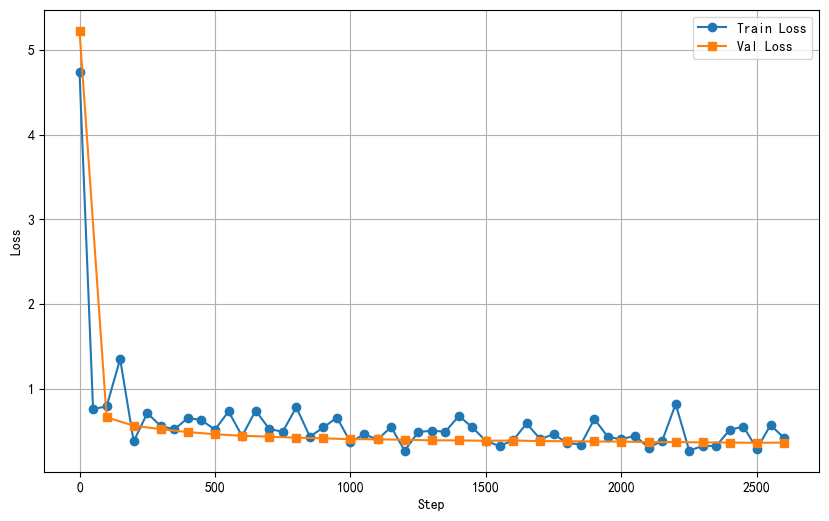

In [46]:
interval = 50
plt.figure(figsize=(10, 6))
plt.plot([x['step'] for x in record_dict['train'][::interval]], [x['loss']
         for x in record_dict['train'][::interval]], label='Train Loss', marker='o')
plt.plot([x['step'] for x in record_dict['val']], [x['loss']
         for x in record_dict['val']], label='Val Loss', marker='s')
plt.legend()
plt.grid()
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [47]:
model.eval()
loss = evaluating(model, test_loader, loss_fn)
print('测试集 MSE Loss:', loss)

测试集 MSE Loss: 0.3936316295312001
